### **1. Configuration & Path Setup**

**goal** : not to have to change any path manually when running the code

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

# Ignore FutureWarnings from Scikit-Learn to clean up plot outputs
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import sys
from pathlib import Path

# 1. Define the Project Root
# Start at the current directory and look for 'src' to identify the root
current_dir = Path.cwd()
project_root = current_dir

while not (project_root / 'src').exists():
    if project_root == project_root.parent:
        # Hit the filesystem root without finding the project
        raise FileNotFoundError("Could not find project root containing 'src'")
    project_root = project_root.parent

# 2. Add Project Root to System Path
# This allows 'import src...' to work from anywhere
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# 3. Define Key Paths
DATA_PATH = project_root / "data"
MODELS_PATH = project_root / "models"

# 4. Verification
print(f"Project Root: {project_root}")
print(f"Data Path:    {DATA_PATH}")
print(f"Models Path:  {MODELS_PATH}")

Project Root: /home/delaunan/code/delaunan/clintrialpredict
Data Path:    /home/delaunan/code/delaunan/clintrialpredict/data
Models Path:  /home/delaunan/code/delaunan/clintrialpredict/models


### **2. Modules Upload**

**goal** : Upload all necessary modules, especially src/prep py functions

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Custom Modules/Closses
from src.prep.data_loader_01 import ClinicalTrialLoader
from src.prep.preprocessing_01 import preprocessor

### **3. Data Load from source files: project_data.csv**

You should delete the one already present in clintrialpredict/data/ if you want the latest version. <br>
if data_project.csv already exists in clintrialpredict/data/, the existing one will not be replaced by the latest one.

In [4]:

# 1. Define path using the '/' operator (works because DATA_PATH is a Path object)
CSV_PATH = DATA_PATH / 'project_data.csv'
FORCE_REGENERATE = False

# 2. Check existence using .exists() method
if CSV_PATH.exists() and not FORCE_REGENERATE:
    print(f">>> Loading existing dataset from: {CSV_PATH}")
    df = pd.read_csv(CSV_PATH)
else:
    print(">>> File not found (or forced regeneration). Triggering ETL pipeline...")

    # Ensure ClinicalTrialLoader is imported from your src
    # from src.WP5_utils.data_loader import ClinicalTrialLoader

    loader = ClinicalTrialLoader(data_path=DATA_PATH)

    # 1. Load & Clean
    df = loader.load_and_clean()

    # 2. Add Features (Hierarchy, Competition, Text)
    df = loader.add_features(df)

    # 3. Save
    loader.save(df, filename='project_data.csv')

print(f"Data Ready. Shape: {df.shape}")

>>> Loading existing dataset from: /home/delaunan/code/delaunan/clintrialpredict/data/project_data.csv
Data Ready. Shape: (33929, 45)


### **3.1 Verification: List of fields in project_data.csv**


In [5]:
df.columns

Index(['nct_id', 'start_date', 'study_type', 'overall_status', 'phase',
       'number_of_arms', 'has_dmc', 'is_fda_regulated_drug', 'start_year',
       'target', 'phase_group', 'includes_us', 'allocation',
       'intervention_model', 'primary_purpose', 'masking',
       'num_primary_endpoints', 'lead_sponsor', 'agency_class',
       'sponsor_clean', 'sponsor_tier', 'gender', 'healthy_volunteers',
       'criteria_len_log', 'child', 'adult', 'older_adult', 'therapeutic_area',
       'therapeutic_subgroup_name', 'txt_primary_endpoints',
       'txt_scientific_essence', 'txt_criteria', 'agent_category',
       'competition_broad', 'competition_niche', 'competition_agent',
       'score_masking', 'score_allocation', 'score_model',
       'design_rigor_score', 'is_gender_restricted', 'is_sick_only',
       'eligibility_strictness_score', 'min_p_value', 'scientific_success'],
      dtype='object')

### **3.2 Verification: Generation of audit file "audit_features.txt" based on project_data.csv**

In [6]:
from src.prep.audit_utils import run_master_audit

#Run the audit of features loaded into project_data.csv (will generate audit_full_report.txt in your data folder)

run_master_audit(DATA_PATH)

>>> Loading data from /home/delaunan/code/delaunan/clintrialpredict/data/project_data.csv...

 1. DATASET HEALTH & INTEGRITY
Dimensions: 33929 Rows x 45 Columns
Global Failure Baseline: 19.2%
Therapeutic Fallback: 0.0% remain Unclassified

 2. CATEGORICAL PREDICTIVE SIGNAL

>>> agent_category (Spread: 39.1%) -> ■ VERY STRONG
PI3K_INHIBITOR                 | 80     | 46.2%
BCL2_INHIBITOR                 | 43     | 34.9%
CELL_THERAPY                   | 176    | 31.2%
KINASE_INHIBITOR_TYROSINE      | 827    | 28.5%
PARP_INHIBITOR                 | 94     | 26.6%
MONOCLONAL_ANTIBODY            | 3664   | 25.3%
ENZYME_INHIBITOR               | 278    | 24.8%
RNA_GENE_THERAPY               | 88     | 22.7%
TARGETED_KINASE_INHIBITOR      | 790    | 22.3%
CHEMOTHERAPY                   | 324    | 22.2%
BTK_INHIBITOR                  | 89     | 20.2%
SMALL_MOLECULE_OTHER           | 16279  | 19.6%
PLACEBO_CTRL                   | 89     | 19.1%
BIOLOGIC_OTHER                 | 2566   | 17.6%
J

### **4. Cleaning of the three NLP txt fields into: project_data_nlp_light.csv"**

**goal**: from src.prep.text_cleaning import day_zero_reconstructor, function to clean all the ~ and other amendments. <br> 
3 fields being prepared and cleaned: <br>
-   'txt_scientific_essence' (official_title [SEP] brief_summary), 
-   'txt_criteria' (patient inclusion criteria), 
-   'txt_primary_endpoints' (list of all primary endpoints defined at start)

In [7]:
import pandas as pd
import importlib
import src.prep.text_cleaning
from src.prep.text_cleaning import day_zero_reconstructor

# 2. Load the master project data using your verified DATA_PATH
df = pd.read_csv(DATA_PATH / "project_data.csv")

# 3. Define the pillars to be sanitized
txt_cols = ['txt_scientific_essence', 'txt_criteria', 'txt_primary_endpoints']

# 4. Apply the sanitization
print(">>> Starting Scientific Sanitization...")
for col in txt_cols:
    if col in df.columns:
        label = col.replace('txt_', '')
        print(f"   Cleaning {col}...")
        df[col] = df[col].astype(str).apply(lambda x: day_zero_reconstructor(x, label))
    else:
        print(f"   [!] Warning: {col} not found in dataframe.")

# 5. Create the Lightweight NLP Dataset for Colab
cols_for_colab = ['nct_id', 'target'] + [t for t in txt_cols if t in df.columns]
df_nlp_light = df[cols_for_colab].copy()

# 6. Save the file
output_file = DATA_PATH / "project_data_nlp_light.csv"
df_nlp_light.to_csv(output_file, index=False)

print(f"\n[SUCCESS] Sanitization complete.")
print(f"File saved for Colab: {output_file}")
print(f"Total rows: {len(df_nlp_light)}")

# 7. Quick Audit
sample_essence = df_nlp_light['txt_scientific_essence'].iloc[0]
print(f"Separator Check: Found {sample_essence.count('[SEP]')} [SEP] tokens in first row.")

>>> Starting Scientific Sanitization...
   Cleaning txt_scientific_essence...
   Cleaning txt_criteria...
   Cleaning txt_primary_endpoints...

[SUCCESS] Sanitization complete.
File saved for Colab: /home/delaunan/code/delaunan/clintrialpredict/data/project_data_nlp_light.csv
Total rows: 33929
Separator Check: Found 1 [SEP] tokens in first row.


### **4.1 Validation: NLP txt fields and cleaning: project_data_nlp_light.csv"**

**goal**: from src.prep.text_cleaning import day_zero_reconstructor, function to clean all the ~ and other amendments. <br> 
3 fields being prepared and cleaned: <br>
-   'txt_scientific_essence' (official_title [SEP] brief_summary), 
-   'txt_criteria' (patient inclusion criteria), 
-   'txt_primary_endpoints' (list of all primary endpoints defined at start)

In [32]:
import pandas as pd
import numpy as np

# 1. Load the generated file
file_path = DATA_PATH / "project_data_nlp_light.csv"
df_audit = pd.read_csv(file_path)

print("="*80)
print(f"FINAL NLP DATASET AUDIT: {file_path.name}")
print("="*80)

# --- SECTION 1: INTEGRITY ---
print(f"\n[1] INTEGRITY CHECK")
print(f"Total Rows: {len(df_audit)}")
print(f"Columns: {df_audit.columns.tolist()}")
nulls = df_audit.isna().sum().sum()
print(f"Missing Values (NaN): {nulls}")

# --- SECTION 2: SANITIZATION (Artifacts) ---
print(f"\n[2] ARTIFACT PERSISTENCE (Should be 0)")
artifacts = ['~', '*', '---', '\\>']
for art in artifacts:
    count = df_audit['txt_criteria'].str.contains(art, regex=False).sum()
    print(f"  - Rows containing '{art}': {count}")

# --- SECTION 3: LEAKAGE REDACTION ---
print(f"\n[3] LEAKAGE REDACTION (Should be 0 or very low)")
# We check for the keywords our regex was supposed to redact
leakage_keywords = ['amendment', 'protocol v', 'revised on', 'updated as of']
for word in leakage_keywords:
    count = df_audit['txt_criteria'].str.contains(word, case=False).sum()
    print(f"  - Rows containing '{word}': {count}")

# --- SECTION 4: SCIENTIFIC PRESERVATION ---
print(f"\n[4] SCIENTIFIC SIGNAL PRESERVATION")
# Ensure our protected terms survived the cleaning
protected = ['RECIST', 'HbA1c', 'ECOG', 'NYHA']
for term in protected:
    count = df_audit['txt_criteria'].str.contains(term, case=False).sum()
    print(f"  - Rows containing '{term}': {count}")

# --- SECTION 5: PILLAR STRUCTURE ---
print(f"\n[5] PILLAR STRUCTURE CHECK")
sep_counts = df_audit['txt_scientific_essence'].str.count(r'\[SEP\]').value_counts()
print("Distribution of [SEP] tokens in Scientific Essence:")
print(sep_counts)

# --- SECTION 6: PLACEHOLDER DENSITY ---
print(f"\n[6] PLACEHOLDER DENSITY (Missing Data Signal)")
for col in ['txt_scientific_essence', 'txt_criteria', 'txt_primary_endpoints']:
    placeholder_count = df_audit[col].str.contains("No .* provided", regex=True).sum()
    print(f"  - {col}: {placeholder_count} rows ({placeholder_count/len(df_audit):.1%})")

print("\n" + "="*80)
print("AUDIT COMPLETE")
print("="*80)

FINAL NLP DATASET AUDIT: project_data_nlp_light.csv

[1] INTEGRITY CHECK
Total Rows: 33929
Columns: ['nct_id', 'target', 'txt_scientific_essence', 'txt_criteria', 'txt_primary_endpoints']
Missing Values (NaN): 0

[2] ARTIFACT PERSISTENCE (Should be 0)
  - Rows containing '~': 0
  - Rows containing '*': 0
  - Rows containing '---': 0
  - Rows containing '\>': 0

[3] LEAKAGE REDACTION (Should be 0 or very low)
  - Rows containing 'amendment': 31
  - Rows containing 'protocol v': 94
  - Rows containing 'revised on': 0
  - Rows containing 'updated as of': 0

[4] SCIENTIFIC SIGNAL PRESERVATION
  - Rows containing 'RECIST': 2218
  - Rows containing 'HbA1c': 2169
  - Rows containing 'ECOG': 4722
  - Rows containing 'NYHA': 2126

[5] PILLAR STRUCTURE CHECK
Distribution of [SEP] tokens in Scientific Essence:
txt_scientific_essence
1    33926
0        3
Name: count, dtype: int64

[6] PLACEHOLDER DENSITY (Missing Data Signal)
  - txt_scientific_essence: 469 rows (1.4%)
  - txt_criteria: 190 rows 

### **5. Google Colab embedding with file *"embed.ipynb"* using *"project_data_nlp_light.csv"***

**goal**: Generation of all embeddings. <br> 
3 files being prepared: <br>
-   biobert_sci_raw.npy: 'txt_scientific_essence' (official_title [SEP] brief_summary), 
-   biobert_crit_raw.npy: 'txt_criteria' (patient inclusion criteria), 
-   biobert_endp_raw.npy: 'txt_primary_endpoints' (list of all primary endpoints defined at start)

### **6. PCA reduction based on training set weights (.fit), transformation applied to val and test *"project_data_nlp_light.csv"***

**goal**: Generation of all embeddings. (apply_temporal_pca) <br> 
3 files being prepared: <br>
-   biobert_sci_raw.npy: '160', 
-   biobert_crit_raw.npy: '160, 
-   biobert_endp_raw.npy: '170'

#### **from src.prep.data_engine import get_temporal_masks, apply_temporal_pca**

    train_mask = df['start_year'] <= 2019
    val_mask = (df['start_year'] >= 2020) & (df['start_year'] <= 2022)
    test_mask = df['start_year'] > 2022

In [33]:
import pandas as pd
import numpy as np
from src.prep.data_engine import get_temporal_masks, apply_temporal_pca

In [34]:
# 1. Load metadata and set nct_id as index
df_meta = pd.read_csv(CSV_PATH).set_index('nct_id')

In [35]:
# 2. Generate masks (now indexed by nct_id)
train_mask, val_mask, test_mask = get_temporal_masks(df_meta)

In [36]:

# 3. Define PCA targets (from your Elbow Analysis)
txt = {
    "crit": {"n": 160, "file": "biobert_crit_raw.npy"},
    "sci":  {"n": 160, "file": "biobert_sci_raw.npy"},
    "endp": {"n": 170, "file": "biobert_endp_raw.npy"}
}

In [37]:
all_pca_dfs = []

# 4. Process with ID-Safety
for name, config in txt.items():

    file_path = DATA_PATH / config['file']
    print(f"Processing {name} from: {file_path}")

    # Check if file exists before loading to avoid generic errors
    if not file_path.exists():
        raise FileNotFoundError(f"Missing embedding file: {file_path}")

    # Load raw array
    raw_arr = np.load(file_path)

    # IMMEDIATELY convert to DataFrame using the IDs from df_meta
    # This assumes the .npy order matches the df_meta order
    df_emb = pd.DataFrame(raw_arr, index=df_meta.index)

    # Run PCA (using the function from your data_engine.py)
    # Ensure apply_temporal_pca is imported
    df_reduced = apply_temporal_pca(df_emb, train_mask, config['n'], name, save_dir=str(MODELS_PATH) + "/")
    all_pca_dfs.append(df_reduced)

Processing crit from: /home/delaunan/code/delaunan/clintrialpredict/data/biobert_crit_raw.npy
Processing sci from: /home/delaunan/code/delaunan/clintrialpredict/data/biobert_sci_raw.npy
Processing endp from: /home/delaunan/code/delaunan/clintrialpredict/data/biobert_endp_raw.npy


### **6.1 Verification: PCA reduction check before final merge**

**goal**: Generation of all embeddings. <br> 
3 files being prepared: <br>
-   biobert_sci_raw.npy: '160', 
-   biobert_crit_raw.npy: '160, 
-   biobert_endp_raw.npy: '170'

In [39]:
# 1. Check the number of NLP txt processed
print(f"Number of pillars in list: {len(all_pca_dfs)} (Expected: 3)")

# 2. Check individual shapes and column naming
for i, df_sub in enumerate(all_pca_dfs):
    pillar_name = df_sub.columns[0].split('_')[0]
    print(f"Pillar {i+1} ({pillar_name}): {df_sub.shape} (Rows, Features)")

# 3. Verify Index Alignment (Crucial for ID-Safety)
# Check if all DataFrames have the exact same nct_ids in the exact same order
first_index = all_pca_dfs[0].index
all_match = all(df_sub.index.equals(first_index) for df_sub in all_pca_dfs)
print(f"All indices match perfectly: {all_match}")

# 4. Preview the Final Concatenation
X_nlp_preview = pd.concat(all_pca_dfs, axis=1)
print(f"\nFinal Matrix Shape: {X_nlp_preview.shape}")
print(f"Total expected features: {160 + 160 + 170} = 490")

# 5. Check for Missing Values
nan_count = X_nlp_preview.isna().sum().sum()
print(f"Total NaN values: {nan_count}")

X_nlp_preview.head()

Number of pillars in list: 3 (Expected: 3)
Pillar 1 (crit): (33929, 160) (Rows, Features)
Pillar 2 (sci): (33929, 160) (Rows, Features)
Pillar 3 (endp): (33929, 170) (Rows, Features)
All indices match perfectly: True

Final Matrix Shape: (33929, 490)
Total expected features: 490 = 490
Total NaN values: 0


,crit_pca_0,crit_pca_1,crit_pca_2,crit_pca_3,crit_pca_4,crit_pca_5,crit_pca_6,crit_pca_7,crit_pca_8,crit_pca_9,...,endp_pca_160,endp_pca_161,endp_pca_162,endp_pca_163,endp_pca_164,endp_pca_165,endp_pca_166,endp_pca_167,endp_pca_168,endp_pca_169
nct_id,,,,,,,,,,,,,,,,,,,,,
NCT00385515,7.668675,1.337552,3.946512,5.182847,3.569701,-0.142577,-4.973563,-3.718871,0.774482,0.831237,...,-0.648264,0.267448,0.671164,0.869310,0.134140,-0.128345,0.048787,0.252051,-0.000997,-0.925237
NCT01744366,-14.488553,2.166785,-0.375803,-0.029271,8.552653,-4.262668,-3.376151,-3.384745,3.005097,5.333294,...,1.305246,-0.696162,1.160824,1.736168,-0.049907,0.130131,-0.131181,1.143165,-0.121871,-0.555594
NCT02267525,6.505092,3.923743,-3.597387,-1.225008,-2.238134,-4.605289,1.318745,0.423660,-0.501753,-1.894277,...,0.255239,0.280501,-1.038982,0.565142,-0.256106,0.339173,0.072034,-0.670471,0.985864,0.158805
NCT05432596,-5.618993,-15.578281,-1.593473,0.667937,-0.102466,2.814280,-1.775717,-5.800665,-0.345582,-0.257389,...,0.215485,0.120207,-1.317218,-0.205623,0.599226,0.482059,-0.678729,-0.324883,0.345420,0.385790
NCT05888103,-10.288657,11.154162,-7.052339,11.205591,-7.856323,-0.383043,-5.214596,2.556749,5.740631,-2.762469,...,-0.384518,-0.942651,-0.770386,-0.228891,-0.795105,-0.395279,0.246645,-0.066204,-0.633675,-0.154948


### **7. Merger of all in dataframe *X_nlp_final***

**goal**: Generation of all embeddings. <br> 
3 files being prepared: <br>
-   biobert_sci_raw.npy: '160', 
-   biobert_crit_raw.npy: '160, 
-   biobert_endp_raw.npy: '170'

In [40]:
# 5. Final Merge (Safe because all have nct_id as index)
X_nlp_final = pd.concat(all_pca_dfs, axis=1)

### **7. Merger of all in dataframe X_nlp_final + check**

490 fields + nct_id = index 490

In [41]:
# 1. Structural Check
print(f"Final Matrix Shape: {X_nlp_final.shape}")
# Expected: (Total Trials, 490)

# 2. Column Prefix Verification
# Ensure we have features from all three scientific pillars
prefixes = X_nlp_final.columns.str.split('_').str[0].unique()
print(f"Pillars detected in columns: {list(prefixes)}")
# Expected: ['crit', 'sci', 'endp']

# 3. ID Integrity Check
# Ensure the index is named 'nct_id' and has no duplicates
print(f"Index Name: {X_nlp_final.index.name}")
print(f"Unique NCT IDs: {X_nlp_final.index.nunique()}")
print(f"Duplicate IDs: {X_nlp_final.index.duplicated().sum()}")

# 4. Data Quality Check
# PCA features should be centered around 0. Let's check the mean of a random sample.
mean_val = X_nlp_final.iloc[:, :10].mean().mean()
print(f"Mean of first 10 PCA features: {mean_val:.4f} (Should be near 0)")

# 5. Missing Data Check
nan_total = X_nlp_final.isna().sum().sum()
print(f"Total Missing Values: {nan_total}")

# 6. Visual Preview
X_nlp_final.head()

Final Matrix Shape: (33929, 490)
Pillars detected in columns: ['crit', 'sci', 'endp']
Index Name: nct_id
Unique NCT IDs: 33929
Duplicate IDs: 0
Mean of first 10 PCA features: 0.0177 (Should be near 0)
Total Missing Values: 0


,crit_pca_0,crit_pca_1,crit_pca_2,crit_pca_3,crit_pca_4,crit_pca_5,crit_pca_6,crit_pca_7,crit_pca_8,crit_pca_9,...,endp_pca_160,endp_pca_161,endp_pca_162,endp_pca_163,endp_pca_164,endp_pca_165,endp_pca_166,endp_pca_167,endp_pca_168,endp_pca_169
nct_id,,,,,,,,,,,,,,,,,,,,,
NCT00385515,7.668675,1.337552,3.946512,5.182847,3.569701,-0.142577,-4.973563,-3.718871,0.774482,0.831237,...,-0.648264,0.267448,0.671164,0.869310,0.134140,-0.128345,0.048787,0.252051,-0.000997,-0.925237
NCT01744366,-14.488553,2.166785,-0.375803,-0.029271,8.552653,-4.262668,-3.376151,-3.384745,3.005097,5.333294,...,1.305246,-0.696162,1.160824,1.736168,-0.049907,0.130131,-0.131181,1.143165,-0.121871,-0.555594
NCT02267525,6.505092,3.923743,-3.597387,-1.225008,-2.238134,-4.605289,1.318745,0.423660,-0.501753,-1.894277,...,0.255239,0.280501,-1.038982,0.565142,-0.256106,0.339173,0.072034,-0.670471,0.985864,0.158805
NCT05432596,-5.618993,-15.578281,-1.593473,0.667937,-0.102466,2.814280,-1.775717,-5.800665,-0.345582,-0.257389,...,0.215485,0.120207,-1.317218,-0.205623,0.599226,0.482059,-0.678729,-0.324883,0.345420,0.385790
NCT05888103,-10.288657,11.154162,-7.052339,11.205591,-7.856323,-0.383043,-5.214596,2.556749,5.740631,-2.762469,...,-0.384518,-0.942651,-0.770386,-0.228891,-0.795105,-0.395279,0.246645,-0.066204,-0.633675,-0.154948


### **7.1 Saving of dataframe *X_nlp_final* in *X_nlp_features_all.csv***

The X_nlp_features_all.csv includes the three PCA txt NLP fields. fit.transform on training data, .transform on val and test data

In [43]:
# Save with index (nct_id) included
# Define the output path using the modular DATA_PATH
output_file = DATA_PATH / "X_nlp_features_all.csv"

# Save with index (nct_id) included
X_nlp_final.to_csv(output_file)

print(f"ID-Safe NLP Matrix Exported to: {output_file}")

ID-Safe NLP Matrix Exported to: /home/delaunan/code/delaunan/clintrialpredict/data/X_nlp_features_all.csv


### **7.2 Merger of *"X_nlp_features_all.csv"* to *"project_data.csv"***

**goal**: Prepare the file for temp test_train_split and preprocessing <br> 
3 categories of fields being merged: <br>
-   crit_pca_x **160**, 
-   sci_pca_x : **160**, 
-   endp_pca_x : **170**

In [8]:
import pandas as pd

# 1. Load Structured Data from project_data.csv
# We set index_col='nct_id' to ensure it matches the NLP features
df_structured = pd.read_csv(DATA_PATH / "project_data.csv", index_col='nct_id')

# 2. Load NLP Features
df_nlp = pd.read_csv(DATA_PATH / "X_nlp_features_all.csv", index_col='nct_id')

# 3. Master Merge
# Inner join ensures we only keep trials present in both files
df = df_structured.merge(df_nlp, left_index=True, right_index=True, how='inner')


### **8. Train Validation Test Split for *"project_data.csv"***

**goal**: Temporal Split Summary:
  - Train: Years <= 2019
  - Val:   Years 2020-2022
  - Test:  Years > 2022

In [9]:
# 4. Use your existing modular function
from src.models.train_test_split import temporal_train_test_split

X_train, X_val, X_test, y_train, y_val, y_test = temporal_train_test_split(
    df,
    train_end_year=2019,
    val_end_year=2022
)


Temporal Split Summary:
  - Train: 28209 samples (Years <= 2019)
  - Val:   4463 samples (Years 2020-2022)
  - Test:  1257 samples (Years > 2022)
  - Features retained in X: ['start_date', 'study_type', 'overall_status', 'phase', 'number_of_arms', 'has_dmc', 'is_fda_regulated_drug', 'start_year', 'phase_group', 'includes_us', 'allocation', 'intervention_model', 'primary_purpose', 'masking', 'num_primary_endpoints', 'lead_sponsor', 'agency_class', 'sponsor_clean', 'sponsor_tier', 'gender', 'healthy_volunteers', 'criteria_len_log', 'child', 'adult', 'older_adult', 'therapeutic_area', 'therapeutic_subgroup_name', 'txt_primary_endpoints', 'txt_scientific_essence', 'txt_criteria', 'agent_category', 'competition_broad', 'competition_niche', 'competition_agent', 'score_masking', 'score_allocation', 'score_model', 'design_rigor_score', 'is_gender_restricted', 'is_sick_only', 'eligibility_strictness_score', 'min_p_value', 'scientific_success', 'crit_pca_0', 'crit_pca_1', 'crit_pca_2', 'crit_pca

In [10]:
# Check for any remaining non-numeric columns (strings or dates)
non_numeric = X_train.select_dtypes(exclude=['number']).columns.tolist()

if non_numeric:
    print(f"CRITICAL: Meta or Categorical data still present: {non_numeric}")
    print("Action: You must encode these or add them to meta_to_drop.")
else:
    print("SUCCESS: X_train is 100% numeric. Ready for the model.")

CRITICAL: Meta or Categorical data still present: ['start_date', 'study_type', 'overall_status', 'phase', 'phase_group', 'allocation', 'intervention_model', 'primary_purpose', 'masking', 'lead_sponsor', 'agency_class', 'sponsor_clean', 'sponsor_tier', 'gender', 'therapeutic_area', 'therapeutic_subgroup_name', 'txt_primary_endpoints', 'txt_scientific_essence', 'txt_criteria', 'agent_category']
Action: You must encode these or add them to meta_to_drop.


In [11]:
def verify_splits(y_train, y_val, y_test):
    for name, y in zip(['Train', 'Val', 'Test'], [y_train, y_val, y_test]):
        count = len(y)
        pos = y.sum()
        rate = y.mean()
        print(f"{name} Set: {count} samples, {pos} Failures, {rate:.2%} Failure Rate")

verify_splits(y_train, y_val, y_test)


Train Set: 28209 samples, 4803 Failures, 17.03% Failure Rate
Val Set: 4463 samples, 1298 Failures, 29.08% Failure Rate
Test Set: 1257 samples, 398 Failures, 31.66% Failure Rate


### **8. Unbalanced dataset. Calculation of  *scale_pos_weight"***

**goal**: scale_pos_weight on training data

In [12]:
import numpy as np

# 1. Count your zeros and ones
num_neg = np.sum(y_train == 0)
num_pos = np.sum(y_train == 1)

# 2. Calculate the ratio (Negatives / Positives)
# If you have fewer 1s, this number will be > 1, telling the model to pay more attention to them.
ratio = float(num_neg) / float(num_pos)

print(f"Count 0s (Negative): {num_neg}")
print(f"Count 1s (Positive): {num_pos}")
print(f"Calculated scale_pos_weight: {ratio:.4f}")

Count 0s (Negative): 23406
Count 1s (Positive): 4803
Calculated scale_pos_weight: 4.8732


### Model Training (model.fit)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from xgboost import XGBClassifier

from src.prep.preprocessing_01 import preprocessor
from sklearn.pipeline import Pipeline


preprocessor_transformer = preprocessor()

# 1. Update the XGBoost parameters with your calculated weight
xgb_model = XGBClassifier(
    n_estimators=494,
    learning_rate=0.02, #Initially 0.042539969815926774
    max_depth=3,                            #Intitially 6
    min_child_weight=25,                    #Intitially 7
    gamma=10,                               #Intitially 0.47449817499360014
    subsample=0.7281024303484277,
    colsample_bytree=0.30,                  #Intitially 0.9136537664042608
    reg_alpha=30,                           #Intitially 3.2880644615017167
    reg_lambda=30,                          #Intitially 2.841543016677358
    scale_pos_weight=ratio,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)



# 2. Re-initialize the Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor_transformer),
    ('classifier', xgb_model)
])

# 3. Training
print("Training the Risk Engine...")
model.fit(X_train, y_train)


# 4. Validation Predictions
# We use X_val which still contains metadata; the pipeline handles the filtering.
y_proba = model.predict_proba(X_val)[:, 1]
y_pred = model.predict(X_val)

# 5. Metrics
print("\n--- Validation Results (2020-2022) ---")
print(classification_report(y_val, y_pred))

roc_auc = roc_auc_score(y_val, y_proba)
pr_auc = average_precision_score(y_val, y_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")


Training the Risk Engine...

--- Validation Results (2020-2022) ---
              precision    recall  f1-score   support

           0       0.87      0.55      0.67      3165
           1       0.42      0.80      0.55      1298

    accuracy                           0.62      4463
   macro avg       0.65      0.68      0.61      4463
weighted avg       0.74      0.62      0.64      4463

ROC-AUC: 0.7347
PR-AUC (Average Precision): 0.5035


In [39]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

def evaluate_per_phase(X_val, y_val, model):
    """
    Slices the validation metrics by trial phase to identify
    strengths and weaknesses in the risk engine.
    """
    # 1. Get probabilities and predictions for the whole set
    y_proba = model.predict_proba(X_val)[:, 1]
    y_pred = model.predict(X_val)

    # 2. Create a temporary evaluation dataframe
    eval_df = X_val[['phase']].copy()
    eval_df['target'] = y_val
    eval_df['pred'] = y_pred
    eval_df['proba'] = y_proba

    phases = sorted(eval_df['phase'].unique())

    print("=== PER-PHASE PERFORMANCE REPORT ===")

    for phase in phases:
        phase_data = eval_df[eval_df['phase'] == phase]

        # Skip if the phase has too few samples or only one class
        if len(phase_data) < 50 or len(phase_data['target'].unique()) < 2:
            continue

        print(f"\n>>> PHASE: {phase}")
        print(f"Samples: {len(phase_data)} | Failure Rate: {phase_data['target'].mean():.2%}")

        # Classification Report
        print(classification_report(phase_data['target'], phase_data['pred']))

        # AUC Metrics
        p_roc_auc = roc_auc_score(phase_data['target'], phase_data['proba'])
        p_pr_auc = average_precision_score(phase_data['target'], phase_data['proba'])

        print(f"ROC-AUC: {p_roc_auc:.4f} | PR-AUC: {p_pr_auc:.4f}")
        print("-" * 30)

# Execute the evaluation
evaluate_per_phase(X_val, y_val, model)

=== PER-PHASE PERFORMANCE REPORT ===

>>> PHASE: PHASE1/PHASE2
Samples: 628 | Failure Rate: 43.31%
              precision    recall  f1-score   support

           0       0.88      0.48      0.62       356
           1       0.58      0.92      0.71       272

    accuracy                           0.67       628
   macro avg       0.73      0.70      0.67       628
weighted avg       0.75      0.67      0.66       628

ROC-AUC: 0.7522 | PR-AUC: 0.6616
------------------------------

>>> PHASE: PHASE2
Samples: 2088 | Failure Rate: 29.65%
              precision    recall  f1-score   support

           0       0.85      0.44      0.58      1469
           1       0.38      0.81      0.52       619

    accuracy                           0.55      2088
   macro avg       0.61      0.63      0.55      2088
weighted avg       0.71      0.55      0.56      2088

ROC-AUC: 0.6860 | PR-AUC: 0.4571
------------------------------

>>> PHASE: PHASE2/PHASE3
Samples: 186 | Failure Rate: 36.56%
 


 PERFORMANCE AUDIT: XGBoost Risk Engine

[1] DISCRIMINATORY POWER (ROC-AUC): 0.7816
    - Industry Benchmark: 0.70 (Public Data) | 0.78+ (Proprietary Data)
    - Status: ✅ Strong

[2] FAILURE DETECTION CAPABILITY (PR-AUC): 0.6088
    - Baseline (Random Guess): 0.3166
    - Lift: 1.9x better than random guessing.

[3] PROBABILITY RELIABILITY (Brier Score): 0.2087
    - Goal: < 0.15 for high-confidence financial modeling.
--------------------------------------------------------------------------------
DETAILED CLASSIFICATION REPORT (With Interpretation):
                precision    recall  f1-score   support

 Completed (0)       0.86      0.62      0.72       859   <-- Correctly approves 62% of safe trials
Terminated (1)       0.49      0.77      0.60       398   <-- Catches 77% of failures (Precision: 49%)

      accuracy                           0.67      1257
     macro avg       0.67      0.70      0.66      1257
  weighted avg       0.74      0.67      0.68      1257



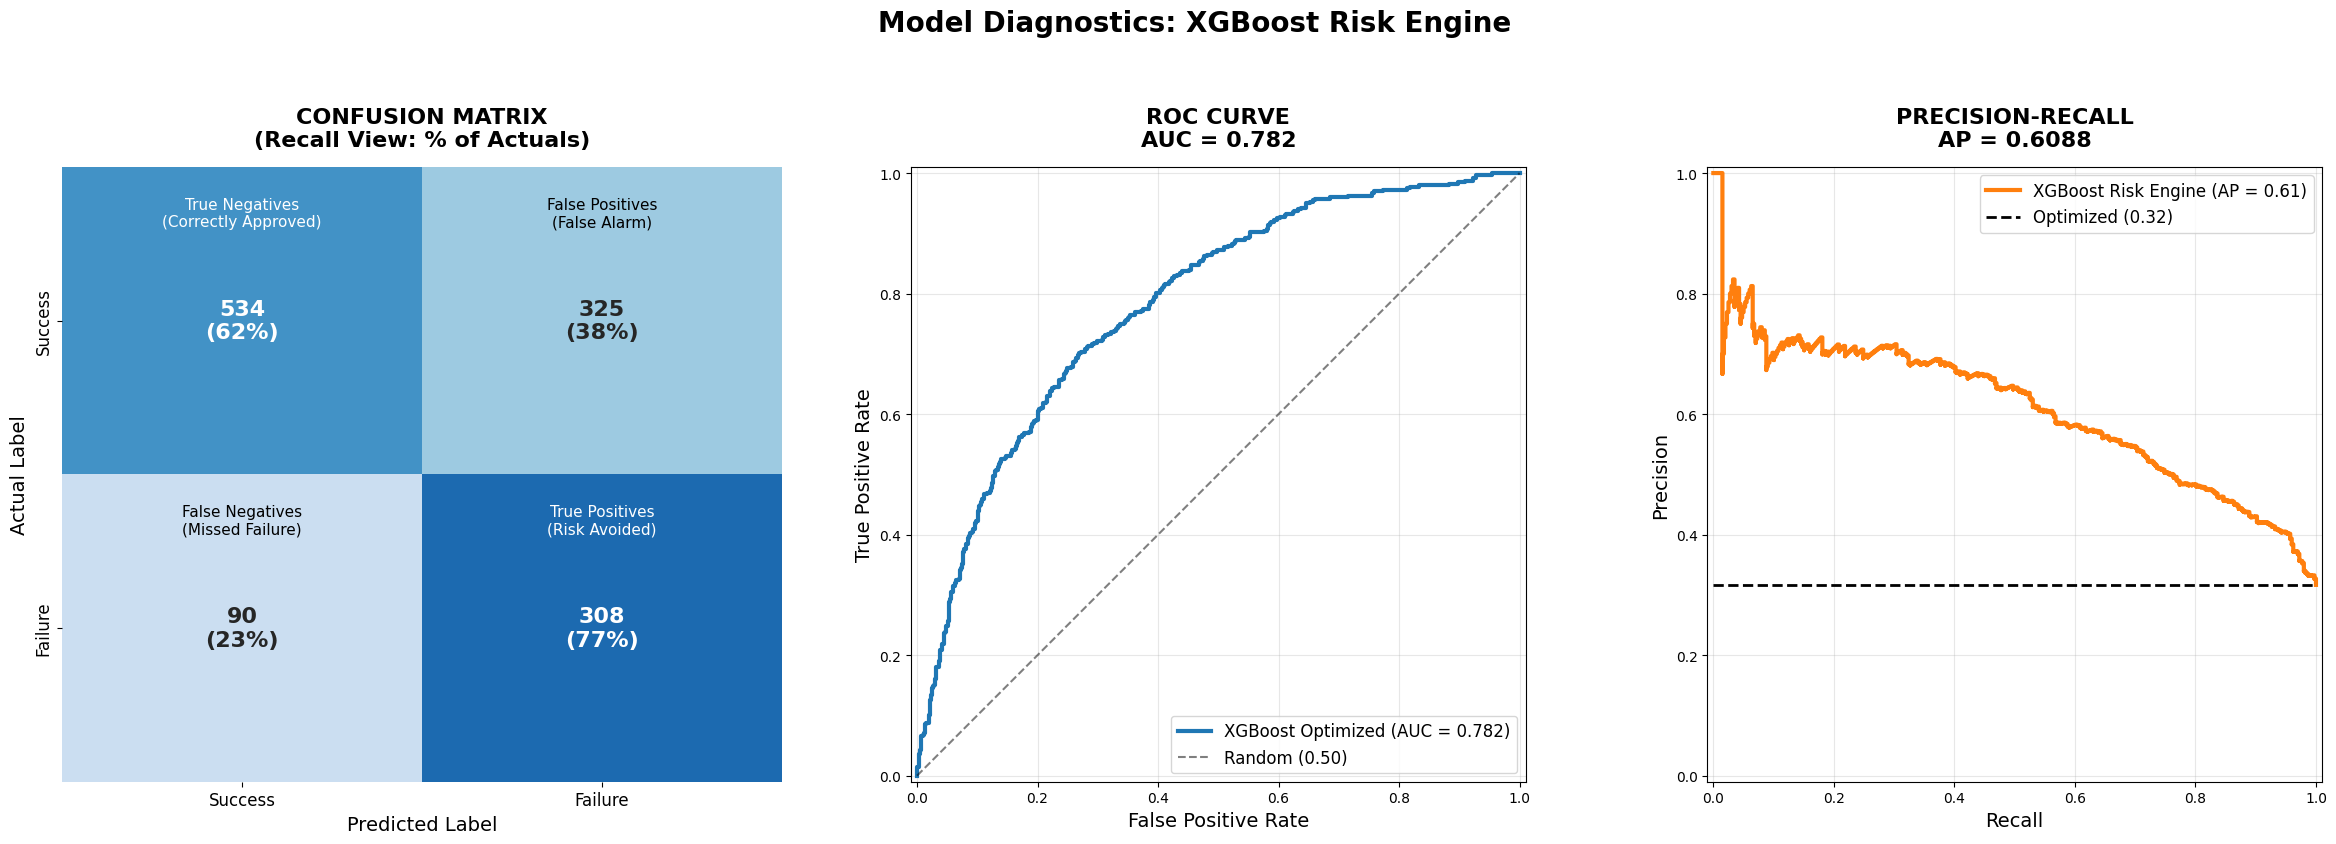


 DIAGNOSTIC: TEMPORAL LEARNING CURVE
Computing learning curve... (This may take a moment)

[RESULTS]
Final Training Score:   0.8949
Final Validation Score: 0.6846
Generalization Gap:     0.2103
>> DIAGNOSIS: High Overfitting. The model is memorizing historical noise.


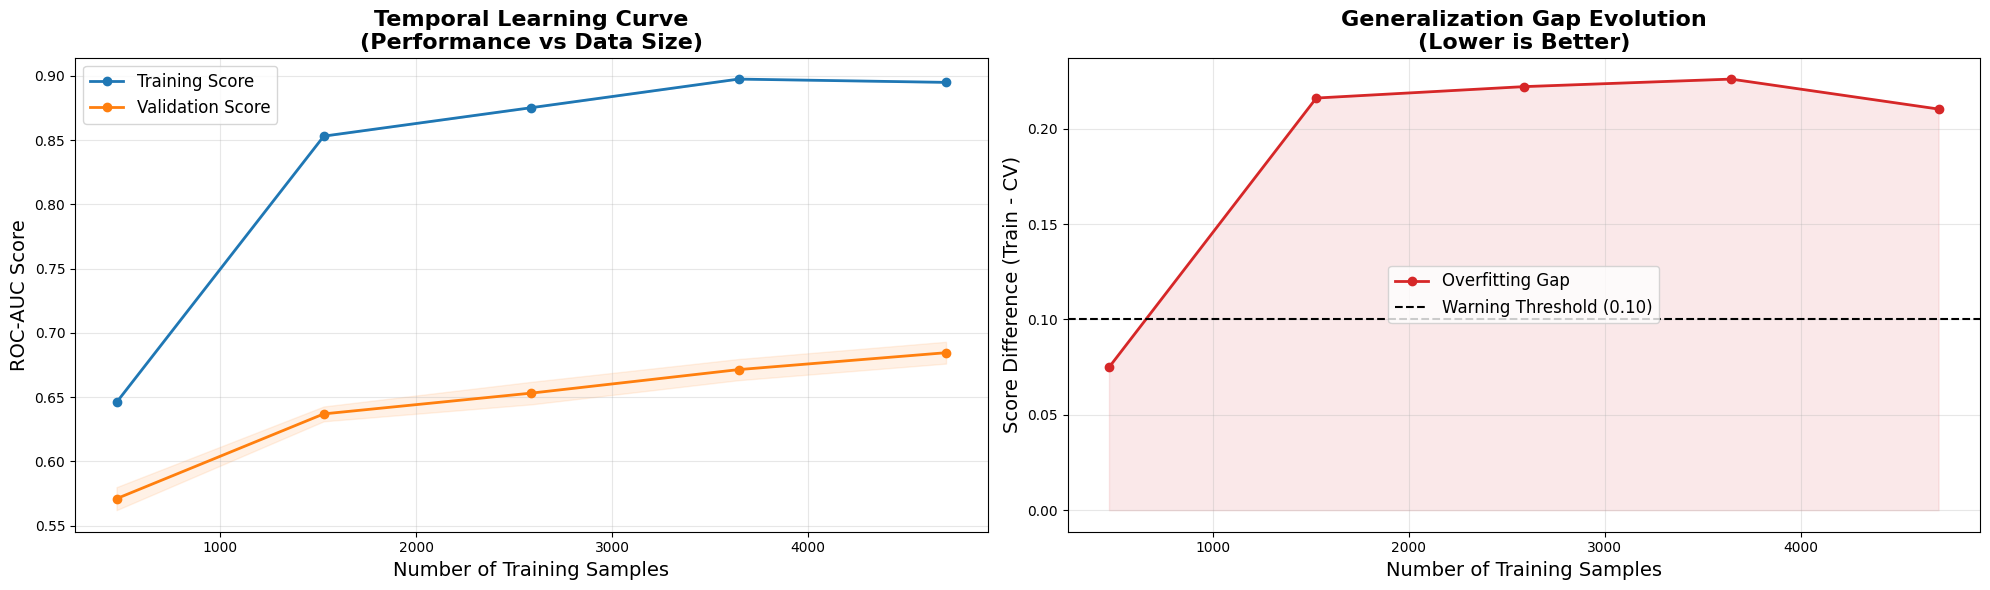


 💼 BUSINESS INTELLIGENCE & VINTAGE ANALYSIS

[1] PERFORMANCE BY SEGMENT
       Dimension                       Segment  Count Fail_Rate ROC_AUC PR_AUC
THERAPEUTIC_AREA                   Respiratory     54     24.1%   0.901  0.634
THERAPEUTIC_AREA                    Hematology     42     54.8%   0.863  0.885
THERAPEUTIC_AREA       Pathological Conditions     43     25.6%   0.832  0.763
THERAPEUTIC_AREA                   Dermatology     50     32.0%   0.798  0.739
THERAPEUTIC_AREA            Congenital/Genetic     40     22.5%   0.774  0.475
THERAPEUTIC_AREA                     Digestive     52     44.2%   0.765  0.724
THERAPEUTIC_AREA Infections (Bacterial/Fungal)    184     22.3%   0.730  0.433
THERAPEUTIC_AREA                  Unclassified    104     12.5%   0.711  0.382
THERAPEUTIC_AREA               Musculoskeletal     35     48.6%   0.703  0.651
THERAPEUTIC_AREA                     Metabolic    106     17.0%   0.688  0.304
THERAPEUTIC_AREA                Cardiovascular     49     

In [40]:
from src.models.evaluate import evaluate_model, plot_learning_curve, evaluate_business_slices

# --- 1. STANDARD EVALUATION ---
# Generates Scorecard, Confusion Matrix, ROC, and PR Curves
metrics = evaluate_model(model, X_test, y_test, model_name="XGBoost Risk Engine")

# --- 2. TEMPORAL LEARNING CURVE ---
# Checks for Overfitting/Underfitting using an expanding window
plot_learning_curve(model, X_train, y_train, cv=5)

# --- 3. BUSINESS INTELLIGENCE & VINTAGE ANALYSIS ---

# Step A: Align Metadata with X_test
# We use the index of X_test (nct_ids) to slice the original 'df'
# This ensures df_test_results has exactly 1,257 rows, perfectly aligned.
if df.index.name != 'nct_id':
    df_indexed = df.set_index('nct_id')
else:
    df_indexed = df

df_test_results = df_indexed.loc[X_test.index].copy()

# Step B: Generate and Attach Predictions
# We generate probabilities and attach them + the true target to the metadata
df_test_results['y_prob'] = model.predict_proba(X_test)[:, 1]
df_test_results['target'] = y_test

# Step C: Run the Business Analysis
# Your evaluate.py function expects a single dataframe containing 'y_prob' and 'target'
evaluate_business_slices(df_test_results)

### How to Read the Graphs (Cheat Sheet)

**1. Confusion Matrix (Operational Impact)**
*   **Bottom Left (False Negatives):** The "Capital Loss" quadrant. The model said "Safe", but the trial failed. Investors lose money here.
*   **Top Right (False Positives):** The "Opportunity Cost" quadrant. The model said "Risky", but the trial succeeded. Pharma misses a good drug here.

**2. ROC Curve (Global Separability)**
*   **What it tells us:** How good is the model generally?
*   **The Line:** The more it hugs the top-left corner, the better.
*   **The Diagonal:** If the line is on the diagonal, the model is guessing (useless).

**3. Precision-Recall Curve (The Imbalance Truth)**
*   **What it tells us:** Can we trust the "Risk" flags?
*   **Context:** Since failures are rare (15%), this is the most honest view.
*   **The Baseline:** The dashed line represents the failure rate (0.15). We want our curve to be significantly higher than this line.

**4. Temporal Learning Curve (Stability)**
*   **Blue Line:** How well the model knows history.
*   **Orange Line:** How well the model predicts the future.
*   **Convergence:** We want the Orange line to go UP and get closer to the Blue line as we add more data. If the Orange line stays flat, adding more data won't help (we need better features).

In [41]:
# Calculate Training Metrics
y_train_proba = model.predict_proba(X_train)[:, 1]
train_roc = roc_auc_score(y_train, y_train_proba)

print(f"--- FINAL GAP ANALYSIS ---")
print(f"Training ROC-AUC:   {train_roc:.4f}")
print(f"Validation ROC-AUC: {roc_auc:.4f}")
print(f"Generalization Gap: {train_roc - roc_auc:.4f}")

--- FINAL GAP ANALYSIS ---
Training ROC-AUC:   0.7794
Validation ROC-AUC: 0.7347
Generalization Gap: 0.0447


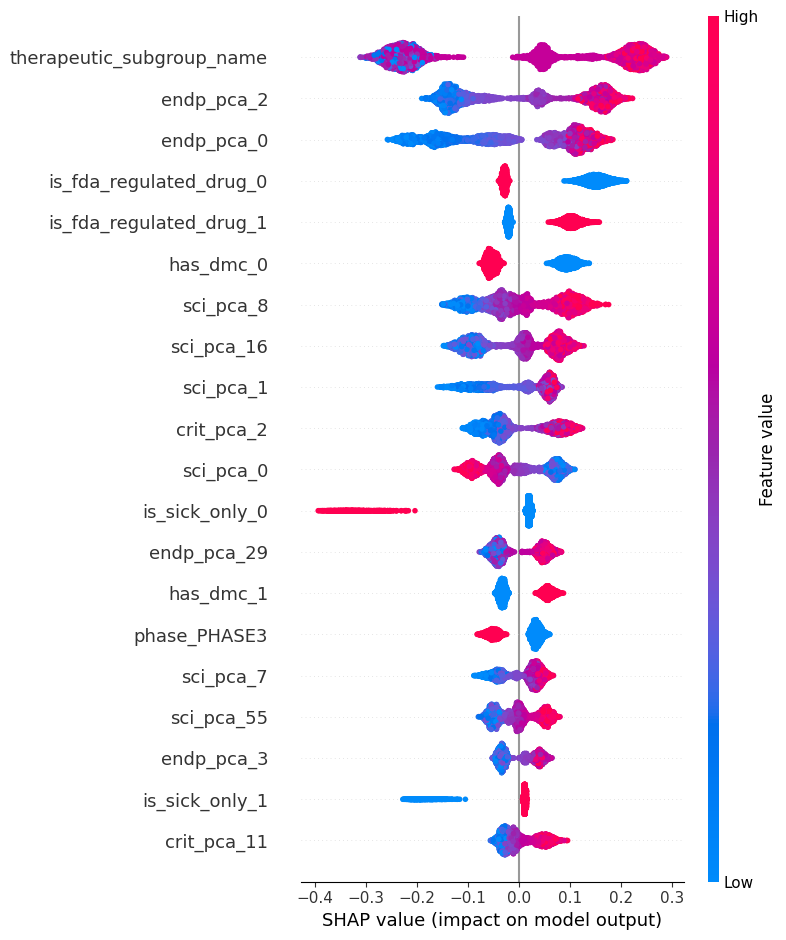

In [42]:
import shap

# 1. Transform the validation data through the preprocessor
X_val_transformed = model.named_steps['preprocessor'].transform(X_val)
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# 2. Initialize SHAP Explainer on the classifier
explainer = shap.TreeExplainer(model.named_steps['classifier'])
shap_values = explainer.shap_values(X_val_transformed)

# 3. Summary Plot
# This will show the top 20 features driving the risk scores
shap.summary_plot(shap_values, X_val_transformed, feature_names=feature_names, max_display=20)

#### 1. The Permutation Test (The "Sanity" Check)
If we shuffle the labels (y_train), the model's performance should collapse to 0.50. If it stays high, your features contain the target in disguise.

In [47]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# 1. Extract the fitted preprocessor from your existing 'model' pipeline
fitted_proc = model.named_steps['preprocessor']

# 2. Generate the numeric matrices
print("Transforming data for stress test...")
X_train_numeric = fitted_proc.transform(X_train)
X_val_numeric = fitted_proc.transform(X_val)

# Convert to DataFrame to keep feature names for the AUC audit
feature_names = fitted_proc.get_feature_names_out()
X_train_final = pd.DataFrame(X_train_numeric, columns=feature_names, index=X_train.index)
X_val_final = pd.DataFrame(X_val_numeric, columns=feature_names, index=X_val.index)

# 3. Define the parameters from your successful "Choked" run
choked_params = {
    'n_estimators': 494,
    'learning_rate': 0.02,
    'max_depth': 3,
    'min_child_weight': 25,
    'gamma': 10,
    'subsample': 0.7281024303484277,
    'colsample_bytree': 0.30,
    'reg_alpha': 30,
    'reg_lambda': 30,
    'tree_method': 'hist',
    'random_state': 42
}

# ---------------------------------------------------------
# TEST 1: PERMUTATION TEST (The "Sanity" Check)
# ---------------------------------------------------------
print("\n--- TEST 1: PERMUTATION TEST ---")
y_train_shuffled = y_train.sample(frac=1, random_state=99).values
fake_model = XGBClassifier(**choked_params, scale_pos_weight=ratio)
fake_model.fit(X_train_final, y_train_shuffled)

y_prob_fake = fake_model.predict_proba(X_val_final)[:, 1]
fake_auc = roc_auc_score(y_val, y_prob_fake)
print(f"Permutation AUC: {fake_auc:.4f}")
print(f"Status: {'✅ PASS' if fake_auc < 0.55 else '❌ FAIL'}")


Transforming data for stress test...

--- TEST 1: PERMUTATION TEST ---
Permutation AUC: 0.4859
Status: ✅ PASS


### 2. The Single-Feature AUC Audit

We will check the ROC-AUC of every single feature. If any single feature (especially a PCA component) has an AUC > 0.70 on its own, it is likely a "Golden Feature" leaker.

In [48]:
print("\n--- TEST 2: SINGLE-FEATURE AUC AUDIT ---")
feature_scores = []
for col in X_train_final.columns:
    try:
        score = roc_auc_score(y_train, X_train_final[col])
        if score < 0.5: score = 1 - score
        feature_scores.append((col, score))
    except:
        continue

df_auc_audit = pd.DataFrame(feature_scores, columns=['feature', 'auc']).sort_values('auc', ascending=False)
print("Top 5 Individual Features by AUC:")
print(df_auc_audit.head(5))
max_auc = df_auc_audit['auc'].max()
print(f"Status: {'✅ PASS' if max_auc < 0.75 else '❌ FAIL'}")


--- TEST 2: SINGLE-FEATURE AUC AUDIT ---
Top 5 Individual Features by AUC:
                       feature       auc
110  therapeutic_subgroup_name  0.644052
272                  sci_pca_1  0.596131
113                 crit_pca_2  0.595544
434                 endp_pca_3  0.575445
431                 endp_pca_0  0.568303
Status: ✅ PASS


### 3. The "Trial Clone" Check
Sometimes a sponsor runs two identical trials (NCT001 and NCT002). If one is in Train and one is in Val, the model "cheats" by recognizing the duplicate.

In [49]:
# TEST 3: TEXTUAL OVERLAP CHECK (The "Clone" Check)
# ---------------------------------------------------------
print("\n--- TEST 3: TEXTUAL OVERLAP CHECK ---")
train_texts = set(df.loc[X_train.index, 'txt_scientific_essence'].unique())
val_texts = df.loc[X_val.index, 'txt_scientific_essence']
overlap = val_texts.isin(train_texts).sum()
overlap_pct = (overlap / len(val_texts)) * 100

print(f"Identical protocols in Train and Val: {overlap} ({overlap_pct:.2f}%)")
print(f"Status: {'✅ PASS' if overlap_pct < 5.0 else '⚠️ WARNING'}")


--- TEST 3: TEXTUAL OVERLAP CHECK ---
Identical protocols in Train and Val: 7 (0.16%)
Status: ✅ PASS


### 4. The "Science-Only" Ablation Test
Run this code to see how the engine performs when it is "blind" to the specific disease name.

In [50]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

# 1. Identify all columns EXCEPT the therapeutic subgroup
# We use the numeric dataframes generated in the previous step
cols_no_disease = [c for c in X_train_final.columns if 'therapeutic_subgroup_name' not in c]

X_train_no_disease = X_train_final[cols_no_disease]
X_val_no_disease = X_val_final[cols_no_disease]

print(f"Ablation Test: Training on {len(cols_no_disease)} features (Disease Subgroup Removed)")

# 2. Re-train the exact same 'Choked' model
science_only_model = XGBClassifier(**choked_params, scale_pos_weight=ratio)
science_only_model.fit(X_train_no_disease, y_train)

# 3. Evaluate
y_prob_science = science_only_model.predict_proba(X_val_no_disease)[:, 1]
science_auc = roc_auc_score(y_val, y_prob_science)
science_pr = average_precision_score(y_val, y_prob_science)

# 4. Comparison Logic
full_model_auc = 0.7347 # From your previous run
auc_drop = full_model_auc - science_auc

print(f"\n--- ABLATION RESULTS ---")
print(f"Full Model AUC (with Disease):    {full_model_auc:.4f}")
print(f"Science-Only AUC (no Disease):   {science_auc:.4f}")
print(f"Performance Drop:                {auc_drop:.4f}")

if science_auc > 0.68:
    print("\n✅ VERDICT: The model is a Scientific Engine. The PCA features provide strong independent signal.")
else:
    print("\n❌ VERDICT: The model is over-reliant on the disease name.")

Ablation Test: Training on 600 features (Disease Subgroup Removed)

--- ABLATION RESULTS ---
Full Model AUC (with Disease):    0.7347
Science-Only AUC (no Disease):   0.7284
Performance Drop:                0.0063

✅ VERDICT: The model is a Scientific Engine. The PCA features provide strong independent signal.


### 5. The "Interaction" Check (SHAP)
If the model is working correctly, it should be using the disease name to "set the baseline" and the PCA features to "adjust the risk." We can verify this by checking if the PCA features still have high SHAP values in the full model.

In [51]:
import shap

# Use the fitted_proc and model from your previous cell
X_val_numeric = fitted_proc.transform(X_val)
feature_names = fitted_proc.get_feature_names_out()

explainer = shap.TreeExplainer(model.named_steps['classifier'])
shap_values = explainer.shap_values(X_val_numeric)

# Calculate mean absolute SHAP values to see total contribution
importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_shap': np.abs(shap_values).mean(axis=0)
}).sort_values(by='mean_shap', ascending=False)

# Calculate the ratio of contribution
disease_contrib = importance_df[importance_df['feature'].str.contains('therapeutic_subgroup_name')]['mean_shap'].sum()
total_contrib = importance_df['mean_shap'].sum()
science_contrib = importance_df[importance_df['feature'].str.contains('_pca_')]['mean_shap'].sum()

print(f"\n--- CONTRIBUTION ANALYSIS ---")
print(f"Disease Subgroup Contribution: {disease_contrib/total_contrib:.2%}")
print(f"Scientific (PCA) Contribution: {science_contrib/total_contrib:.2%}")


--- CONTRIBUTION ANALYSIS ---
Disease Subgroup Contribution: 7.17%
Scientific (PCA) Contribution: 69.71%


## Features simplification

### 1. The "Dead Weight" Audit (Built-in Importance)
This identifies features that the model never used to make a single decision.

In [53]:
import pandas as pd

# 1. Extract importances from the fitted classifier
xgb_feat_importances = model.named_steps['classifier'].feature_importances_
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# 2. Create a DataFrame
df_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_feat_importances
}).sort_values(by='importance', ascending=True)

# 3. Identify Zero-Importance Features
zero_imp_features = df_imp[df_imp['importance'] == 0]['feature'].tolist()

print(f"--- DEAD WEIGHT AUDIT ---")
print(f"Total features: {len(feature_names)}")
print(f"Features with ZERO importance: {len(zero_imp_features)}")
print(f"Example zero-importance features: {zero_imp_features[:10]}")

--- DEAD WEIGHT AUDIT ---
Total features: 601
Features with ZERO importance: 139
Example zero-importance features: ['therapeutic_area_Gastrointestinal', 'therapeutic_area_Endocrine', 'therapeutic_area_ENT (Ear/Nose/Throat)', 'therapeutic_area_Digestive', 'therapeutic_area_Dermatology', 'therapeutic_area_Congenital/Genetic', 'therapeutic_area_Chemically Induced', 'therapeutic_area_Cardiovascular', 'sci_pca_52', 'therapeutic_area_Neurology']


### 2. The "Noise" Audit (Permutation Importance)
This is the most rigorous test. It measures the "Real World" value of a feature on unseen data.

In [52]:
from sklearn.inspection import permutation_importance

# 1. Transform validation data
X_val_proc = model.named_steps['preprocessor'].transform(X_val)

# 2. Run Permutation Importance (using a sample for speed)
print("Running Permutation Importance (this may take a minute)...")
perm_results = permutation_importance(
    model.named_steps['classifier'],
    X_val_proc,
    y_val,
    scoring='roc_auc',
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# 3. Organize results
df_perm = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_results.importances_mean,
    'importance_std': perm_results.importances_std
}).sort_values(by='importance_mean', ascending=True)

# 4. Identify Noise (Negative Importance)
# A negative mean means the model actually performs BETTER when this feature is randomized.
noise_features = df_perm[df_perm['importance_mean'] <= 0]['feature'].tolist()

print(f"\n--- NOISE AUDIT ---")
print(f"Features that are pure noise (<= 0 impact): {len(noise_features)}")
print(f"Top 10 most harmful/useless features:\n{df_perm.head(10)}")

Running Permutation Importance (this may take a minute)...

--- NOISE AUDIT ---
Features that are pure noise (<= 0 impact): 314
Top 10 most harmful/useless features:
           feature  importance_mean  importance_std
69   includes_us_0        -0.000877        0.000549
122    crit_pca_11        -0.000561        0.000593
277      sci_pca_6        -0.000499        0.000168
432     endp_pca_1        -0.000482        0.000083
70   includes_us_1        -0.000465        0.000287
326     sci_pca_55        -0.000410        0.000551
128    crit_pca_17        -0.000405        0.000157
278      sci_pca_7        -0.000360        0.000335
322     sci_pca_51        -0.000360        0.000169
501    endp_pca_70        -0.000359        0.000205


In [54]:
# 1. Create the Stability DataFrame
df_stability = pd.DataFrame({
    'feature': feature_names,
    'train_gain': model.named_steps['classifier'].feature_importances_,
    'perm_mean': perm_results.importances_mean,
    'perm_std': perm_results.importances_std
})

# 2. Define "Safe to Prune" Logic
# A feature is safe to prune ONLY if:
# - It is a PCA component (we keep all structured data for safety)
# - Its training gain is 0
# - Its permutation importance is negative OR its mean is less than its standard deviation
def identify_safe_pruning(row):
    if "_pca_" not in row['feature']:
        return "KEEP: Domain Logic"

    if row['train_gain'] == 0 and row['perm_mean'] <= 0:
        # If the noise is larger than the signal, it's truly useless
        if abs(row['perm_mean']) > row['perm_std']:
            return "PRUNE: Consistent Noise"
        else:
            return "KEEP: Unstable/Potential"

    return "KEEP: Active Signal"

df_stability['verdict'] = df_stability.apply(identify_safe_pruning, axis=1)

# 3. Summary
print("--- PRUNING STABILITY AUDIT ---")
print(df_stability['verdict'].value_counts())

# 4. List the "Consistent Noise" features
prune_list = df_stability[df_stability['verdict'] == "PRUNE: Consistent Noise"]['feature'].tolist()
print(f"\nRecommended for deletion: {len(prune_list)} features")

--- PRUNING STABILITY AUDIT ---
verdict
KEEP: Active Signal         430
KEEP: Domain Logic          111
KEEP: Unstable/Potential     60
Name: count, dtype: int64

Recommended for deletion: 0 features


## Calibration and Decreasing False Positives (false alarms)

#### Implementation Step 1: Isotonic Calibration
We use the Validation set (X_val) to "teach" the model how to correct its own overconfidence before testing it on the unseen Test set (X_test).


In [77]:
from sklearn.calibration import CalibratedClassifierCV

# Initialize the calibrator using the pre-trained XGBoost model
# We use 'isotonic' because we have a sufficiently large validation set
# 'prefit' ensures we don't re-train the underlying XGBoost logic
calibrator = CalibratedClassifierCV(model, cv='prefit', method='isotonic')

# Fit the calibrator on the Validation set
# This maps XGBoost scores to real-world probability of termination
calibrator.fit(X_val, y_val)

# Generate calibrated probabilities for the Test set
y_prob_calibrated = calibrator.predict_proba(X_test)[:, 1]

print(f"Calibration complete. Probabilities now reflect historical failure frequencies.")

Calibration complete. Probabilities now reflect historical failure frequencies.


#### Implementation: Reliability Visualization

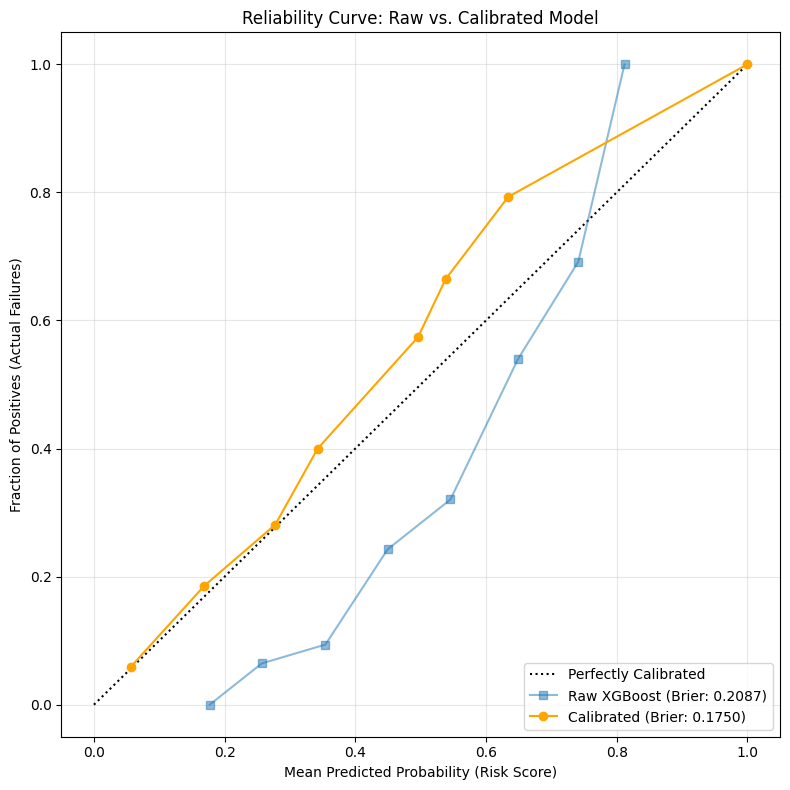

Brier Score Improvement: 16.16% reduction in error.


In [78]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# 1. Calculate Raw Probabilities for comparison
y_prob_raw = model.predict_proba(X_test)[:, 1]

# 2. Calculate Brier Scores (Lower is better)
brier_raw = brier_score_loss(y_test, y_prob_raw)
brier_cal = brier_score_loss(y_test, y_prob_calibrated)

# 3. Generate Calibration Curves
# n_bins=10 is standard for clinical datasets to ensure enough samples per bin
prob_true_raw, prob_pred_raw = calibration_curve(y_test, y_prob_raw, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_prob_calibrated, n_bins=10)

# 4. Visualization
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated")

plt.plot(prob_pred_raw, prob_true_raw, "s-", label=f"Raw XGBoost (Brier: {brier_raw:.4f})", alpha=0.5)
plt.plot(prob_pred_cal, prob_true_cal, "o-", label=f"Calibrated (Brier: {brier_cal:.4f})", color='orange')

plt.xlabel("Mean Predicted Probability (Risk Score)")
plt.ylabel("Fraction of Positives (Actual Failures)")
plt.title("Reliability Curve: Raw vs. Calibrated Model")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Brier Score Improvement: {((brier_raw - brier_cal) / brier_raw):.2%} reduction in error.")

### Step 2: Threshold Optimization

In [80]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# 1. Calculate Precision, Recall, and Thresholds
# We use the calibrated probabilities from the previous step
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_calibrated)

# 2. Calculate F1-Score for every threshold
# F1 = 2 * (precision * recall) / (precision + recall)
# Note: We handle the zero-division case internally
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# 3. Find the index of the maximum F1-Score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal Threshold (Max F1): {best_threshold:.4f}")
print(f"Resulting Precision: {precisions[best_idx]:.4f}")
print(f"Resulting Recall:    {recalls[best_idx]:.4f}")
print(f"Resulting F1-Score:  {best_f1:.4f}")

# 4. Optional: Find a "High Precision" threshold for conservative alerts
# This finds the threshold where precision first hits 70%
target_p = 0.70
if any(precisions >= target_p):
    p_idx = np.where(precisions >= target_p)[0][0]
    print(f"\nAlternative 'High Confidence' Threshold (Precision > {target_p}): {thresholds[p_idx]:.4f}")
    print(f"Recall at this level: {recalls[p_idx]:.4f}")

Optimal Threshold (Max F1): 0.3131
Resulting Precision: 0.5371
Resulting Recall:    0.7085
Resulting F1-Score:  0.6111

Alternative 'High Confidence' Threshold (Precision > 0.7): 0.5956
Recall at this level: 0.1332


### Step 3: Confusion Matrix & Risk Tiering

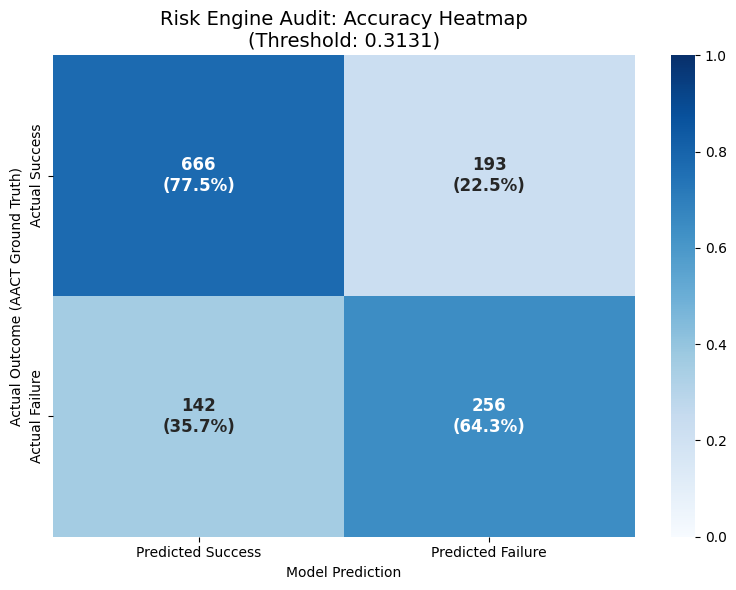

RISK TIER DISTRIBUTION (TEST SET)
Risk_Tier
Low         47.5%
High        29.9%
Moderate    16.8%
Critical     5.8%
Name: proportion, dtype: object

Classification Report at 0.3131:
              precision    recall  f1-score   support

     Success       0.82      0.78      0.80       859
     Failure       0.57      0.64      0.60       398

    accuracy                           0.73      1257
   macro avg       0.70      0.71      0.70      1257
weighted avg       0.74      0.73      0.74      1257



In [83]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Apply the Optimal Thresholds
best_threshold = 0.3131
high_conf_threshold = 0.5956
y_pred_optimal = (y_prob_calibrated >= best_threshold).astype(int)

# 2. Generate Confusion Matrix Data
cm_counts = confusion_matrix(y_test, y_pred_optimal)
# Normalize by row (Actual Outcome) so color reflects accuracy/recall
cm_perc = cm_counts.astype('float') / cm_counts.sum(axis=1)[:, np.newaxis]

# 3. Create Combined Labels (Count + Percentage)
# We use cm_counts for the number and cm_perc for the percentage
labels = [f"{count}\n({perc:.1%})" for count, perc in zip(cm_counts.flatten(), cm_perc.flatten())]
labels = np.asarray(labels).reshape(2, 2)

# 4. Visualization: Color by Percentage, Label by Count + Percentage
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_perc,           # Color intensity is now driven by percentages (0.0 to 1.0)
    annot=labels,      # Text displays both Count and Percentage
    fmt="",
    cmap="Blues",
    xticklabels=['Predicted Success', 'Predicted Failure'],
    yticklabels=['Actual Success', 'Actual Failure'],
    annot_kws={"size": 12, "weight": "bold"},
    vmin=0, vmax=1     # Ensure the color scale is consistent (0% to 100%)
)

plt.title(f"Risk Engine Audit: Accuracy Heatmap\n(Threshold: {best_threshold})", fontsize=14)
plt.ylabel("Actual Outcome (AACT Ground Truth)")
plt.xlabel("Model Prediction")
plt.tight_layout()
plt.show()

# 5. Define Risk Tiering Logic
def assign_risk_tier(prob):
    if prob < 0.20:
        return "Low"
    elif prob < best_threshold:
        return "Moderate"
    elif prob < high_conf_threshold:
        return "High"
    else:
        return "Critical"

# 6. Create Results DataFrame for Audit
results_df = pd.DataFrame({
    'Actual_Outcome': y_test,
    'Risk_Probability': y_prob_calibrated
})
results_df['Risk_Tier'] = results_df['Risk_Probability'].apply(assign_risk_tier)

# 7. Final Audit Prints
print(f"{'='*40}")
print("RISK TIER DISTRIBUTION (TEST SET)")
print(f"{'='*40}")
print(results_df['Risk_Tier'].value_counts(normalize=True).map("{:.1%}".format))
print(f"\nClassification Report at {best_threshold}:")
print(classification_report(y_test, y_pred_optimal, target_names=['Success', 'Failure']))

### Verifying the tiers

In [84]:
# Group by Risk Tier and calculate the ACTUAL failure rate in each bucket
tier_audit = results_df.groupby('Risk_Tier')['Actual_Outcome'].agg(['count', 'mean']).reindex(['Low', 'Moderate', 'High', 'Critical'])

# Rename 'mean' to 'Actual_Failure_Rate' for clarity
tier_audit.columns = ['Trial_Count', 'Actual_Failure_Rate']

print("PROBABILITY VALIDATION PER TIER:")
print(tier_audit)

# Interpretation:
# In a well-calibrated model, the 'Actual_Failure_Rate' for the 'Critical' tier
# should be significantly higher than the 'Low' tier.

PROBABILITY VALIDATION PER TIER:
           Trial_Count  Actual_Failure_Rate
Risk_Tier                                  
Low                597             0.132328
Moderate           211             0.298578
High               376             0.539894
Critical            73             0.726027


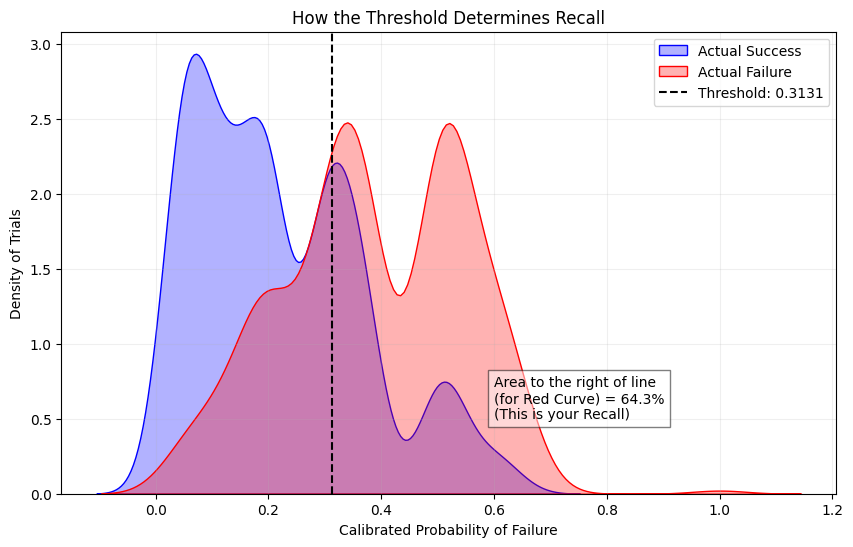

Mathematical Verification:
Total Actual Failures: 398
Failures with Prob >= 0.3131: 256
Calculated Recall: 64.32%


In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Separate probabilities by actual outcome
prob_success = results_df[results_df['Actual_Outcome'] == 0]['Risk_Probability']
prob_failure = results_df[results_df['Actual_Outcome'] == 1]['Risk_Probability']

# 2. Plot the distributions
plt.figure(figsize=(10, 6))
sns.kdeplot(prob_success, label='Actual Success', fill=True, color='blue', alpha=0.3)
sns.kdeplot(prob_failure, label='Actual Failure', fill=True, color='red', alpha=0.3)

# 3. Draw the Threshold Line
plt.axvline(best_threshold, color='black', linestyle='--', label=f'Threshold: {best_threshold}')

# 4. Annotate the Recall Area
plt.text(0.6, 0.5, f"Area to the right of line\n(for Red Curve) = {cm_perc[1,1]:.1%}\n(This is your Recall)",
         fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

plt.title("How the Threshold Determines Recall")
plt.xlabel("Calibrated Probability of Failure")
plt.ylabel("Density of Trials")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# 5. Manual Verification Code
actual_failures = results_df[results_df['Actual_Outcome'] == 1]
captured_failures = actual_failures[actual_failures['Risk_Probability'] >= best_threshold]
calculated_recall = len(captured_failures) / len(actual_failures)

print(f"Mathematical Verification:")
print(f"Total Actual Failures: {len(actual_failures)}")
print(f"Failures with Prob >= {best_threshold}: {len(captured_failures)}")
print(f"Calculated Recall: {calculated_recall:.2%}")

### Save model (not to have to re-run model.fit next time so that you start with the correct weights)
prerequisite will be Train_test_split to recuperate the X_train, y_train, X_test, y_test to feed into pretrained model.

In [18]:
import joblib

# 1. Define the filename in a variable
MODEL_FILENAME = 'logreg_baseline.joblib'

# 2. Construct the full path using the pathlib object
# This ensures it goes to 'CLINTRIALPREDICT/models/', not 'src/models/'
save_path = MODELS_PATH / MODEL_FILENAME

# 3. Save the model
print(f"Saving model to: {save_path} ...")
joblib.dump(model, save_path)

print(f"✅ Model successfully saved as '{MODEL_FILENAME}' in the project root models folder.")

Saving model to: /home/delaunan/code/delaunan/clintrialpredict/models/logreg_baseline.joblib ...
✅ Model successfully saved as 'logreg_baseline.joblib' in the project root models folder.


### Imprort pre-trained model (not to have to re-run model.fit)
prerequisite Train_test_split to recuperate the X_train, y_train, X_test, y_test to feed into pretrained model.

In [ ]:
# Import the loader
from src.models.model_utils import load_model

# Retrieve the model from the file
my_loaded_model = load_model('logreg_baseline.joblib')

# Verify it works by making a prediction on the first 5 rows of test data
print("\nTesting loaded model...")
sample_probs = my_loaded_model.predict_proba(X_test.head(5))[:, 1]
print(f"Predictions for first 5 trials: {sample_probs}")

>>> Loading model from: /home/delaunan/code/delaunan/clintrialpredict/src/models/logreg_model.joblib

Testing loaded model...
Predictions for first 5 trials: [0.40835685 0.31814536 0.59581191 0.11837591 0.33292536]
